# This notebook shows you how to access the remotely stored processed data

# Initial set up

## These steps help you build the project on a local machine. 
If you are using nrp Jupyterhub, it is recommended you use the provided block instead.

#### Build the project
- ```pip install .[plotting]```

#### Install aws cli (optional)
You will want to install this if you want to manually see the data stored in the nrp bucket.

Example for installing on linux :
- ```sudo curl "https://awscli.amazonaws.com/awscli-exe-linux-x86_64.zip" -o "awscliv2.zip"```
- ```sudo unzip awscliv2.zip```
- ```sudo ./aws/install```

### Note about optional dependencies
If you have already built the project with ```pip install .``` make sure you rebuild with ```pip install .[plotting]``` as we will be using these optional packages here.

## Running in NRP Jupyterhub

This is for running this notebook on nrp Jupyterhub. 

This block simply builds the project and installs dependencies not already present on nrp jupyterhub.
You can safely ignore pip warnings

For serious projects, users should use conda or docker but this notebook is meant to be very simple and user friendly.

In [2]:
RUNNING_ON_NRP = False
if (RUNNING_ON_NRP):
    %pip install -e ../. --no-deps

    %pip install xgcm
    %pip install zarr
    %pip install boto3
    %pip install ujson
    %pip install scikit-fmm
    %pip install aiobotocore
    %pip install cmocean

## Set AWS credentials
If you are accessing or writing data to S3, you must set credentials.
NOTE : S3 is all that is supported currently.
This typically corresponds to an NRP S3 bucket.

windows:

- ```$env:AWS_ACCESS_KEY_ID="..."```
- ```$env:AWS_SECRET_ACCESS_KEY="..."```

unix:

- ```export AWS_ACCESS_KEY_ID=...```
- ```export AWS_SECRET_ACCESS_KEY=...```

In [3]:
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
from matplotlib.colors import BoundaryNorm

import dbof.dataset_creation.zarr_dataset as zarr_dataset
import dbof.io.filesystems as filesystems

# Load DBOF

## Dataset access config

For convenience the parameters used in accessing the dataset can be stored in config files under ```configs/data_access/```.
These values must match the run configurations.

Example config:
```
data_access:
  s3_endpoint: "https://s3-west.nrp-nautilus.io"
  bucket: "llc"
  folder: "native_grid_dbof_training_data"
  run_id: "year_4x150"
```

If the user prefers, these values can also simply be hardcoded when using the package.

In [4]:
#path_to_config = "../configs/data_access/1year_4_snapshots.yaml"
path_to_config = "../configs/data_access/test.yaml"
with open(path_to_config) as f:
    data_cfg = yaml.safe_load(f)["data_access"]

bucket = data_cfg["bucket"]
folder = data_cfg["folder"]
s3_endpoint = data_cfg["s3_endpoint"]
feature_channels = data_cfg["feature_channels"]
run_id = data_cfg["run_id"] # If you generated your own dataset make sure and update the run_id here or in your own config.

run_id = "vort_03"


# User can also simply do
# bucket = "bucket"
# folder = "folder"
# .
# .
# .

In [5]:
# Build our file system for accessing remote files
fs, fs_synch = filesystems.create_s3_filesystems(s3_endpoint)

# Metadata
First we will load in the metadata. The metadata has per cutout information for each datapoint in our dataset

In [6]:
# A dataset run generates many metadata files.
files = fs_synch.glob(
    f"{bucket}/{folder}/{run_id}/metadata/*.parquet"
)

meta_df = pd.read_parquet(files, filesystem=fs_synch)

In [7]:
# A quick look at the metadata
meta_df

,id,dataset_index,native_grid,center_grid_face,center_grid_j,center_grid_i,center_lat,center_lon,target_km_res,real_km_w,real_km_h,pre_interp_res,log_grad_b_2_center,time_snapshot
0,c4fcc6be-a635-4128-bdad-ae37405112cc,b'c62dba1ae0a147559136c1278626b3df',LLC4320,2,2170,486,48.529819,-27.864584,150,147.250160,148.364525,"[104, 97]",-19.955426,2011-11-01 04:00:00
1,f6820bb7-bbbb-4e0b-b042-841bf736efe1,b'e67e590e80124b849d06f3af682444e6',LLC4320,4,1143,926,-42.628166,71.302086,150,149.967415,148.839662,"[95, 89]",-20.756724,2011-11-01 04:00:00
2,020f9a9d-4080-4b5c-a051-64d08c8b31eb,b'98d6aa5946454f68af015b5e38c9a747',LLC4320,10,3082,2722,40.619553,-63.781250,150,148.257057,147.681044,"[85, 92]",-19.170793,2011-11-01 04:00:00
3,94147976-3bef-4782-b0e5-3e3786f78b68,b'4994727a58ce4a608cf1684ba90c8784',LLC4320,4,2137,1559,-27.034576,84.489586,150,148.544068,147.939311,"[79, 73]",-19.633362,2011-11-01 04:00:00
4,8e675cb9-ed09-4505-a8a2-6b069ee2ef3a,b'aac83132ca434b218cb07e438a40c83c',LLC4320,7,1885,3702,24.882320,-178.718750,150,146.775310,147.083569,"[71, 77]",-21.122760,2011-11-01 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,fd62a7b0-af93-4762-b07a-c10db2c0516e,b'd93376a998fe4f49808e8631a3a6576f',LLC4320,10,2782,3085,35.105118,-70.031250,150,148.522693,147.800431,"[79, 86]",-19.371778,2012-01-31 10:00:00
296,39c94a77-60b9-42a0-92f9-5d6467273dcd,b'ff29a8fee3044ca78ce9870e88abd754',LLC4320,11,510,358,6.962801,-117.364586,150,148.769989,147.143391,"[65, 71]",-21.689448,2012-01-31 10:00:00
297,4baecf16-b064-47f8-b338-7eade8803009,b'5148b275ef9f4055975c8285b291423f',LLC4320,2,1567,193,40.178509,-33.968750,150,148.651699,147.562518,"[91, 85]",-20.415523,2012-01-31 10:00:00
298,b8ddf5df-29ec-4de3-80a0-663d15fedb2c,b'675ed870658342a188fd8fd4b6fe9fd5',LLC4320,11,1400,548,3.314291,-98.822914,150,147.872786,147.988687,"[65, 70]",-19.800812,2012-01-31 10:00:00


### A pdf of the log divergence of buoyancy squared found in our metadata
This value is stored in the metadata as a center point as this center point is what the data is currently sampled by.

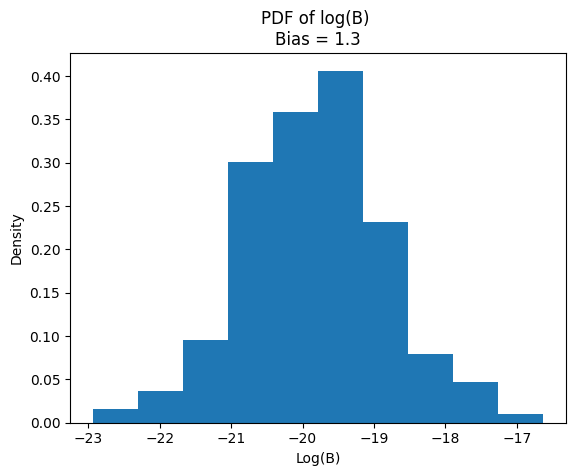

In [8]:
hist, edges = np.histogram(meta_df["log_grad_b_2_center"], bins=10, density=True)

plt.bar(
    edges[:-1],
    hist,
    width=np.diff(edges),
    align="edge"
)

plt.xlabel("Log(B)")
plt.ylabel("Density")
plt.title("PDF of log(B) \nBias = 1.3")

plt.show()

### A look at the geospatial sampling location of each cutout

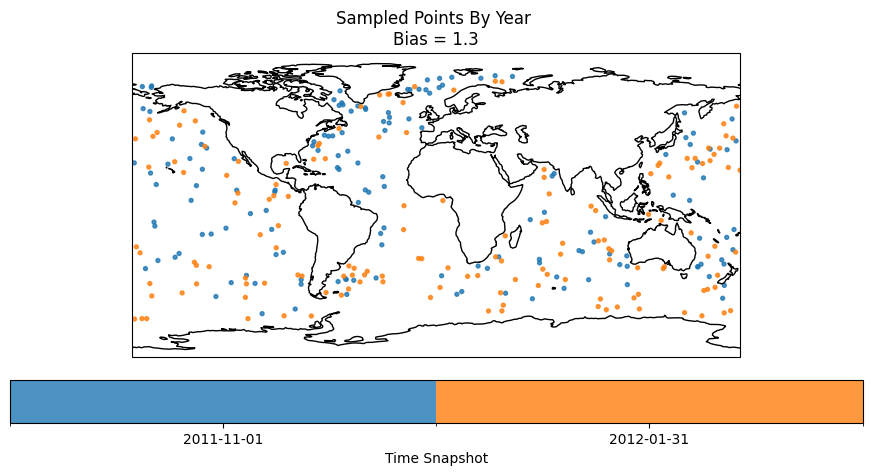

In [9]:
lats = meta_df["center_lat"].values
lons = meta_df["center_lon"].values

timestamps = pd.to_datetime(meta_df["time_snapshot"])

timestamps = pd.Series(u.strftime("%Y-%m-%d") for u in timestamps)

unique_times = timestamps.sort_values().unique()

time_to_index = {t: i for i, t in enumerate(unique_times)}

time_indices = np.array([time_to_index[t] for t in timestamps])
n_times = len(unique_times)

# discrete colormap
cmap = plt.get_cmap("tab10")#, n_times)
norm = BoundaryNorm(np.arange(-0.5, n_times + 0.5, 1), n_times)


fig = plt.figure(figsize=(11, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_global()
ax.coastlines()

sc = ax.scatter(
    lons,
    lats,
    c=time_indices,
    cmap=cmap,
    norm=norm,
    s=8,
    alpha=0.8,
    transform=ccrs.PlateCarree()
)

# discrete colorbar with timestamp labels
cbar = plt.colorbar(
    sc,
    ax=ax,
    orientation="horizontal",
    pad=0.06,
    ticks=np.arange(n_times)
)

cbar.set_ticklabels([str(t) for t in unique_times])
cbar.set_label("Time Snapshot")

plt.title("Sampled Points By Year \nBias = 1.3")
plt.show()

# Load the data cutouts

In [10]:
# This reader class will allow easy access to the remotely stored data

reader = zarr_dataset.ZarrDatasetReader(
    bucket=bucket,
    folder=folder,
    run_id=run_id,
    dataset_name="dataset_creation.zarr",
    fs=fs
)

### Plot some data samples and cooresponding metadata

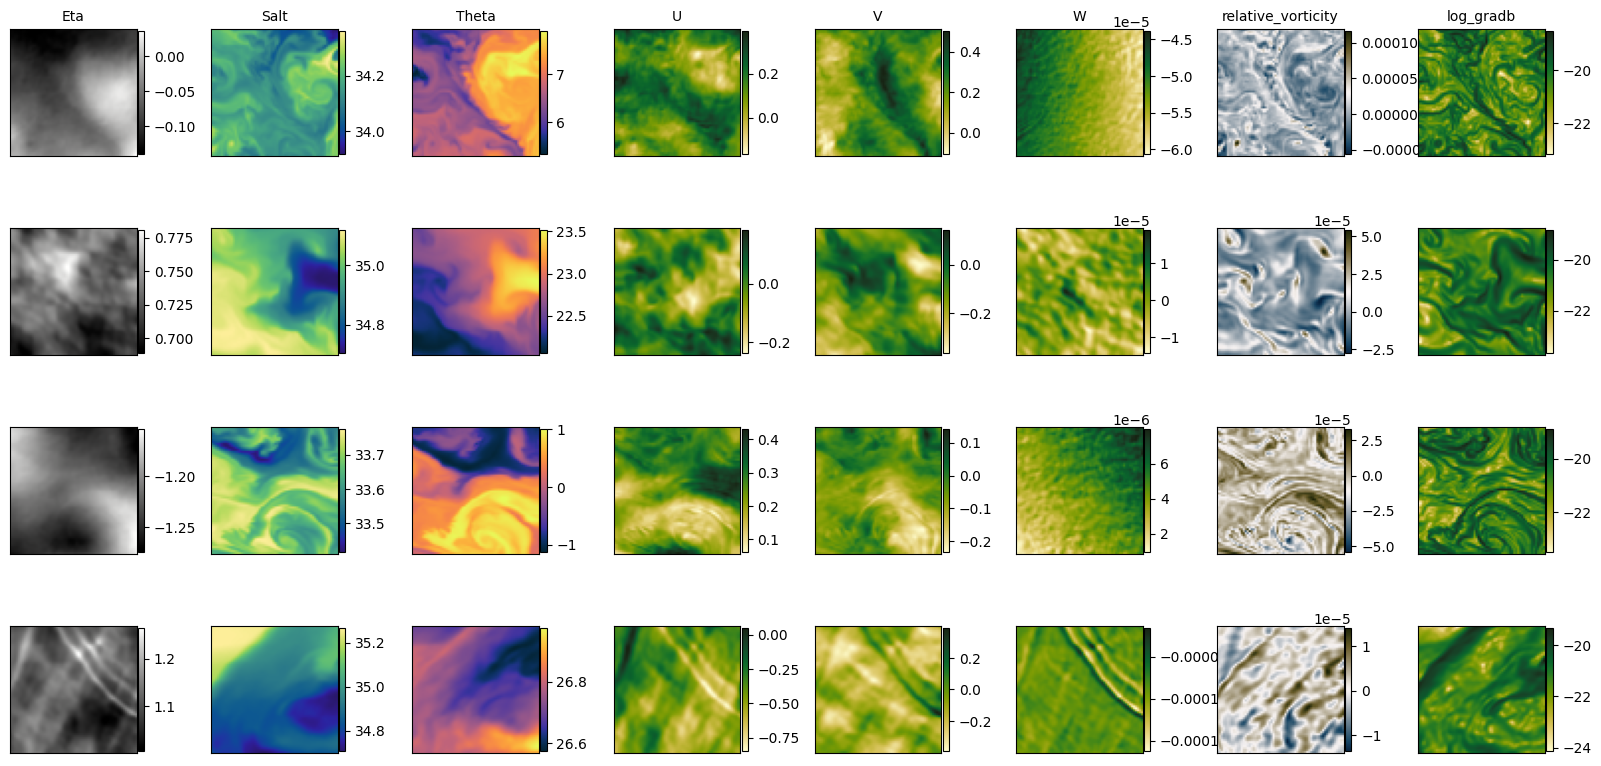

,dataset_index,id,native_grid,center_grid_face,center_grid_j,center_grid_i,center_lat,center_lon,target_km_res,real_km_w,real_km_h,pre_interp_res,log_grad_b_2_center,time_snapshot
0,b'441594b1a3d4417f867f1dec3b0c4d7e',c86a51b1-65d5-4a9c-86ec-efd7308b856c,LLC4320,2,3713,1670,66.144760,-3.907633,150,149.710414,149.864808,"[136, 151]",-20.101660,2011-11-01 04:00:00
1,b'faa0591e25b54a129e63eb55c3b78652',7328f38a-0c5e-450e-83fa-0703644c1463,LLC4320,7,3287,4023,19.186695,-149.510422,150,148.853570,148.752640,"[69, 75]",-20.069948,2012-01-31 10:00:00
2,b'40e334ee13e343ccb0c90df5989c9cc8',a9ee4952-23a0-4d3e-90af-15617a4cb5ad,LLC4320,0,3757,3307,-62.768875,30.906250,150,148.378706,148.699175,"[144, 141]",-21.016694,2012-01-31 10:00:00
3,b'56932ee2e4db43cca06337303a59668b',52e9d9e5-a9f8-469d-b76b-d61d29490598,LLC4320,4,3146,174,-8.717032,55.635418,150,146.524328,147.982729,"[71, 65]",-21.200876,2011-11-01 04:00:00


In [11]:
# todo it would be cool to add a lat lon pin to each sample

import cmocean


def plot_image_features(imgs, ids):
    """
    imgs: (N, C, H, W)
    """

    N, C, H, W = imgs.shape

    fig = plt.figure(figsize=(2.5*(C+1), 2.5*N))
    gs = fig.add_gridspec(N, C + 1, wspace=0.5, hspace=0.15)

    for i in range(N):
        row_data = imgs[i]

        for c in range(C):
            ax = fig.add_subplot(gs[i, c])

            # vmin = np.nanmin(row_data[c])
            # vmax = np.nanmax(row_data[c])


            if c == 0:
                cmap = cmocean.cm.gray
            elif c == 1 :
                cmap = cmocean.cm.haline
            elif c == 2 :
                cmap = cmocean.cm.thermal
            elif c == 6 :
                cmap = cmocean.cm.diff
            else :
                cmap = cmocean.cm.speed



            im = ax.imshow(row_data[c], cmap=cmap) #, vmin=vmin, vmax=vmax)
            ax.set_xticks([])
            ax.set_yticks([])

            if i == 0:
                ax.set_title(f"{feature_channels[c]}", fontsize=10)

            fig.colorbar(
                im,
                ax=ax,
                fraction=0.046,
                pad=0.01 #format="%4.2"
            )

    plt.show()

rand_indices = np.random.randint(0, reader.num_images, size=4)
imgs, ids = reader.get_images(rand_indices)

plot_image_features(imgs, ids)

# Metadata for each sample
subset_df = (
    meta_df
    .set_index("dataset_index")
    .loc[ids]
    .reset_index()
)
subset_df

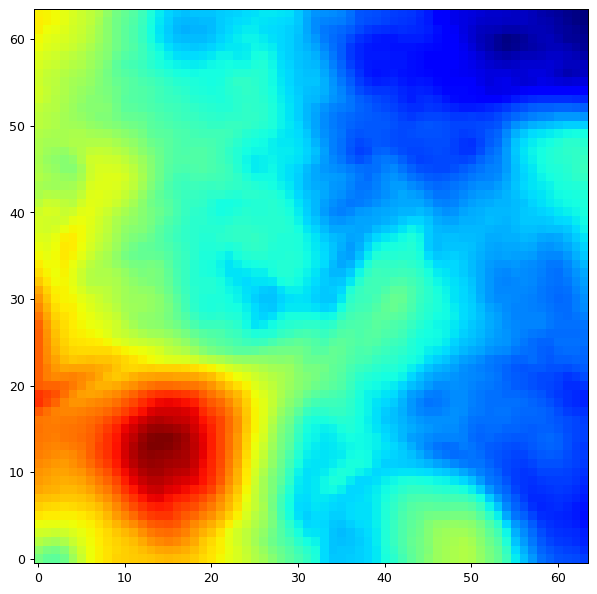

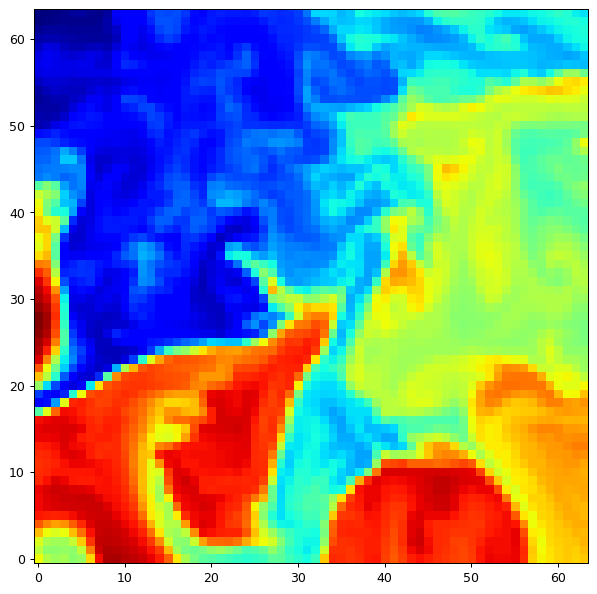

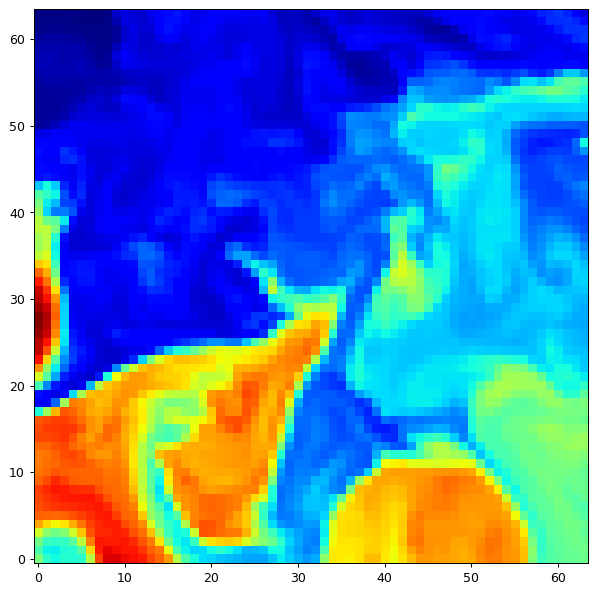

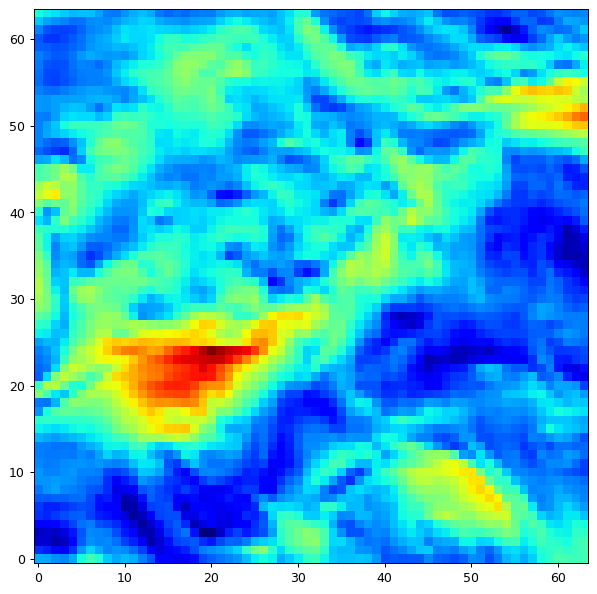

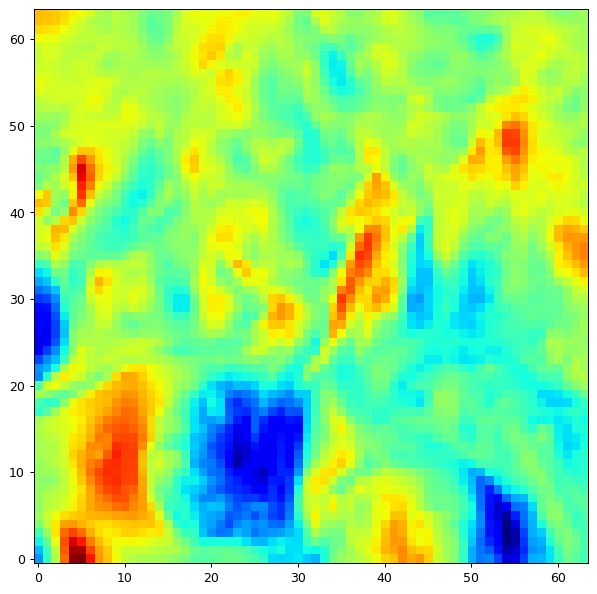

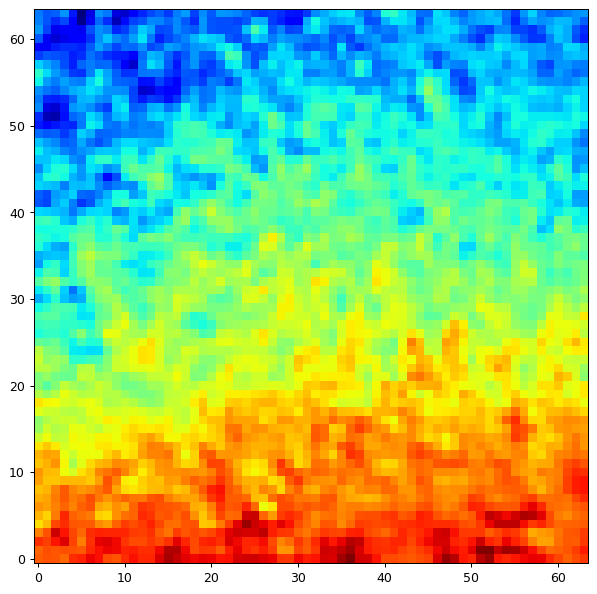

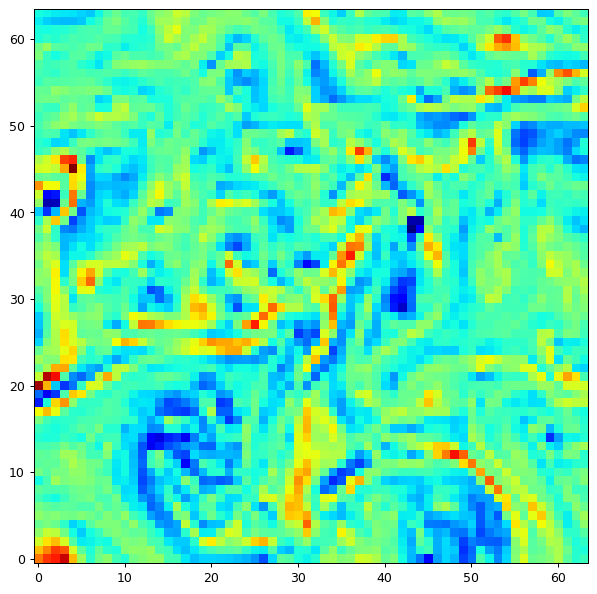

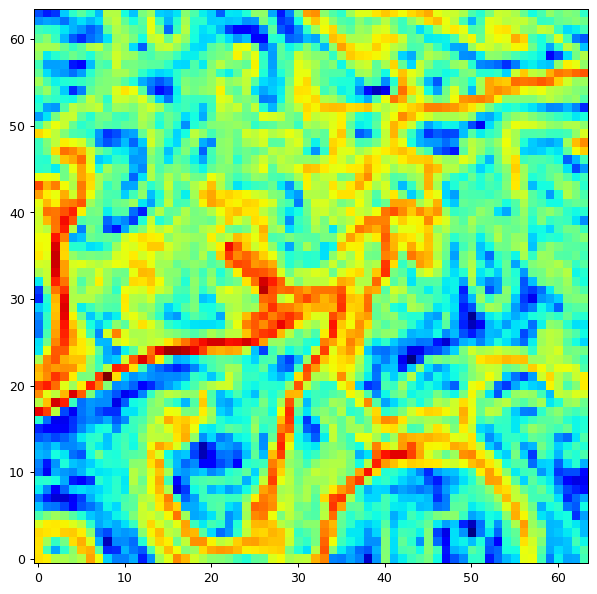

In [12]:
# Plot out every feature of an image from our data

img, img_id = reader.get_image(10)
for i in range(len(img)):

    plt.figure(figsize=(8,8), dpi= 90)
    plt.imshow(img[i],origin='lower',cmap='jet')